# 자치구별 유동인구, 주차확보율, 민원 점수 분석

이 노트북은 `branch_SG/traffic_analystic` 폴더의 데이터를 사용해 자치구별 유동인구와 주차장확보율의 상관관계를 보고, 주차장확보율 기반 주차 문제 점수와 인구보정 민원 문제 점수를 산출합니다.

- 월별 유동인구 파일의 `month`는 분기 대표월로 간주합니다.
- `1월/2월 -> 1분기`, `5월 -> 2분기`, `8월 -> 3분기`, `11월 -> 4분기`로 변환합니다.
- 분기 총 유동인구수는 대표월 값에 `3`을 곱합니다.
- 점수 산출은 `연도-분기-자치구` 단위로 집계한 뒤 수행합니다.
- 민원은 인구 1만 명당 민원으로 보정한 뒤, 많을수록 높은 문제 점수로 환산합니다.
- 문제 점수는 5~95 분위수 기반 min-max를 적용한 뒤 10~90 범위로 압축합니다.

In [21]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import font_manager

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

# ── 한글 폰트 자동 탐색 ──────────────────────────────────────────
_font_candidates = [
    Path('C:/Windows/Fonts/malgun.ttf'),
    Path('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'),
    Path('/System/Library/Fonts/Supplemental/AppleGothic.ttf'),
]
font_path = next((p for p in _font_candidates if p.exists()), None)
if font_path:
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ────────────────────────────────────────────────────
# 노트북 위치: KM/traffic/complain/
# 데이터:      KM/traffic/complain/data/
# 버스/지하철: KM/traffic/bus_subway/
DATA_DIR = Path('data')
BUS_DIR  = Path('../bus_subway')
OUT_DIR  = DATA_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MONTHLY_PATH   = next(DATA_DIR.glob('monthly_scores_*.csv'), None)
BUS_PATH       = BUS_DIR / 'bus_gu_wide.csv'
SUBWAY_PATH    = BUS_DIR / 'subway_gu_wide.csv'
GARBAGE_PATH   = DATA_DIR / 'garbage_collection_status.csv'
PARKING_PATH   = next(DATA_DIR.glob('주차장*확보율*.csv'), None)
COMPLAINT_PATH = next(DATA_DIR.glob('*민원건수*.xlsx'), None)

# ── 경로 검증 ────────────────────────────────────────────────────
all_ok = True
for label, path in {
    'MONTHLY':   MONTHLY_PATH,
    'BUS':       BUS_PATH,
    'SUBWAY':    SUBWAY_PATH,
    'GARBAGE':   GARBAGE_PATH,
    'PARKING':   PARKING_PATH,
    'COMPLAINT': COMPLAINT_PATH,
}.items():
    exists = bool(path) and Path(path).exists()
    print(f'[{"OK" if exists else "NOT FOUND"}] {label}: {path}')
    if not exists:
        all_ok = False

if not all_ok:
    missing_files = [str(p) for p in [MONTHLY_PATH, BUS_PATH, SUBWAY_PATH,
                                       GARBAGE_PATH, PARKING_PATH, COMPLAINT_PATH]
                     if not (p and Path(p).exists())]
    raise FileNotFoundError(
        f'필수 파일이 없습니다: {missing_files}\n'
        f'  data/ 폴더 내용: {[f.name for f in DATA_DIR.iterdir()] if DATA_DIR.exists() else "폴더 없음"}\n'
        f'  bus_subway/ 폴더 내용: {[f.name for f in BUS_DIR.iterdir()] if BUS_DIR.exists() else "폴더 없음"}'
    )

[OK] MONTHLY: data\monthly_scores_문헌기반_서울.csv
[OK] BUS: ..\bus_subway\bus_gu_wide.csv
[OK] SUBWAY: ..\bus_subway\subway_gu_wide.csv
[OK] GARBAGE: data\garbage_collection_status.csv
[OK] PARKING: data\주차장+확보율_2022_2024.csv
[OK] COMPLAINT: data\자치구별 지표별 연도별 민원건수 현황.xlsx


In [22]:
def read_csv_smart(path, **kwargs):
    encodings = ['utf-8-sig', 'utf-8', 'cp949', 'euc-kr']
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError as exc:
            last_error = exc
    raise last_error

def find_col(df, include=None, exclude=None, exact=None, required=False, label='컬럼'):
    include = include or []
    exclude = exclude or []
    exact = exact or set()
    for col in df.columns:
        if str(col).strip() in exact:
            return col
    for col in df.columns:
        name = str(col).strip().lower()
        if all(k.lower() in name for k in include) and not any(k.lower() in name for k in exclude):
            return col
    if required:
        raise KeyError(f'{label}을 찾지 못했습니다. include={include}, exact={exact}')
    return None

def find_cols(df, any_keywords, all_keywords=None, exclude=None):
    all_keywords = all_keywords or []
    exclude = exclude or []
    result = []
    for col in df.columns:
        name = str(col).strip().lower()
        if any(k.lower() in name for k in any_keywords) and all(k.lower() in name for k in all_keywords) and not any(k.lower() in name for k in exclude):
            result.append(col)
    return result

def quantile_scaled_100(series, higher_is_worse=True, lower_q=0.05, upper_q=0.95, out_min=10, out_max=90):
    s = pd.to_numeric(series, errors='coerce')
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        midpoint = (out_min + out_max) / 2
        return pd.Series(np.where(s.notna(), midpoint, np.nan), index=s.index)
    scaled = (s - lo) / (hi - lo)
    score = scaled * (out_max - out_min) + out_min
    score = score.clip(out_min, out_max)
    return score if higher_is_worse else out_max + out_min - score

def load_parking_csv(path):
    """
    주차장 CSV 로드.
    멀티 헤더 형식(row0=연도, row1=지표명, row2+=데이터)과
    단일 헤더 형식 모두 처리한다.
    연도가 여러 개 있을 경우 3개년 평균으로 집계한다.
    """
    if path is None:
        return pd.DataFrame(columns=['gu_name', 'registered_cars', 'parking_spaces', 'parking_supply_rate'])

    raw = read_csv_smart(path, header=None)

    # row1 에 지표명이 있는지 확인 (멀티 헤더 판별)
    row1_vals = raw.iloc[1].astype(str).tolist()
    is_multi = any('등록' in v or '주차면' in v or '확보율' in v for v in row1_vals)

    if is_multi:
        # ── 멀티 헤더: row0=연도, row1=지표, row2+=데이터 ──────────
        year_row   = raw.iloc[0].astype(str).tolist()
        metric_row = raw.iloc[1].astype(str).tolist()

        # 고유 컬럼명: idx0·idx1 은 자치구 구분, 이후는 year_metric
        new_cols = [f'_col{i}' for i in range(2)]
        for y, m in zip(year_row[2:], metric_row[2:]):
            new_cols.append(f'{y.strip()}_{m.strip()}')

        df = raw.iloc[2:].copy().reset_index(drop=True)
        df.columns = new_cols

        # 두 번째 컬럼이 자치구명 (자치구(2))
        df = df.rename(columns={'_col1': 'gu_name'}).drop(columns=['_col0'])
        df = df[df['gu_name'].notna()]
        df['gu_name'] = df['gu_name'].astype(str).str.strip()
        df = df[~df['gu_name'].isin(['소계', '자치구(2)', ''])]

        # 연도별 지표 컬럼 분류
        reg_cols    = [c for c in df.columns if '등록대수' in c or '등록' in c]
        space_cols  = [c for c in df.columns if '주차면수' in c]
        supply_cols = [c for c in df.columns if '확보율' in c]

        for cols in [reg_cols, space_cols, supply_cols]:
            for c in cols:
                df[c] = pd.to_numeric(df[c], errors='coerce')

        # 3개년 평균
        df['registered_cars']    = df[reg_cols].mean(axis=1)    if reg_cols    else np.nan
        df['parking_spaces']     = df[space_cols].mean(axis=1)  if space_cols  else np.nan
        df['parking_supply_rate']= df[supply_cols].mean(axis=1) if supply_cols else np.nan

    else:
        # ── 단일 헤더: row0=컬럼명, row1+=데이터 ────────────────────
        header = raw.iloc[1].astype(str).tolist()
        df = raw.iloc[2:].copy()
        df.columns = ['level_1', 'gu_name'] + header[2:]
        df = df[df['gu_name'].ne('소계')].copy()
        df['gu_name'] = df['gu_name'].astype(str).str.strip()

        rename = {}
        for col in df.columns:
            name = str(col)
            if '자동차등록대수' in name or '등록대수' in name:
                rename[col] = 'registered_cars'
            elif '주차면수' in name:
                rename[col] = 'parking_spaces'
            elif '주차장확보율' in name or '확보율' in name:
                rename[col] = 'parking_supply_rate'
        df = df.rename(columns=rename)

        for col in ['registered_cars', 'parking_spaces', 'parking_supply_rate']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

    keep = ['gu_name', 'registered_cars', 'parking_spaces', 'parking_supply_rate']
    for c in keep[1:]:
        if c not in df.columns:
            df[c] = np.nan
    return df[keep].reset_index(drop=True)

def load_complaint_excel(path):
    if path is None:
        return pd.DataFrame(columns=['year', 'gu_name', 'traffic_complaints', 'safety_complaints', 'environment_complaints'])
    df = pd.read_excel(path)
    rename = {}
    for col in df.columns:
        name = str(col).strip()
        if name == '자치구명':
            rename[col] = 'gu_name'
        elif name == '연도':
            rename[col] = 'year'
        elif '교통' in name and '민원' in name:
            rename[col] = 'traffic_complaints'
        elif '안전' in name and '민원' in name:
            rename[col] = 'safety_complaints'
        elif '환경' in name and '민원' in name:
            rename[col] = 'environment_complaints'
    df = df.rename(columns=rename)
    complaint_value_cols = [c for c in ['traffic_complaints', 'safety_complaints', 'environment_complaints'] if c in df.columns]
    for col in ['year'] + complaint_value_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['year'] = df['year'].astype('Int64')
    keep = ['year', 'gu_name'] + complaint_value_cols
    return df[keep]

def show_shape(name, df):
    print(f'{name}: {df.shape[0]:,}행 x {df.shape[1]:,}열')

## 1. 데이터 불러오기

In [23]:

monthly_raw = read_csv_smart(MONTHLY_PATH)
bus_raw = read_csv_smart(BUS_PATH)
subway_raw = read_csv_smart(SUBWAY_PATH)
garbage_raw = read_csv_smart(GARBAGE_PATH)
parking_raw = load_parking_csv(PARKING_PATH)
complaint_raw = load_complaint_excel(COMPLAINT_PATH)

for name, df in [('monthly', monthly_raw), ('bus', bus_raw), ('subway', subway_raw), ('garbage', garbage_raw), ('parking', parking_raw), ('complaint', complaint_raw)]:
    show_shape(name, df)
    display(df.head(3))

monthly: 8,350행 x 15열


,연도,월,자치구코드,자치구명,총이동인구수,평균이동시간,총이동시간,유입인구_norm,평균이동시간_norm,총이동시간_norm,출퇴근스트레스점수,가중치_유입인구,가중치_평균이동시간,가중치_총이동시간,원본파일
0,2022,1,11240,송파구,563446.22,44.981302,2.534454e+07,1.000000,0.294432,1.000000,75.305122,0.45,0.35,0.2,NaN
1,2022,1,11230,강남구,556713.94,44.413550,2.472564e+07,0.984099,0.260583,0.967871,72.762264,0.45,0.35,0.2,NaN
2,2022,1,11160,강서구,394817.34,42.776841,1.688904e+07,0.601708,0.163004,0.561046,44.002897,0.45,0.35,0.2,NaN


bus: 25행 x 74열


,gu_code,gu_name,202201_geton,202201_getoff,202202_geton,202202_getoff,202203_geton,202203_getoff,202204_geton,202204_getoff,...,202408_geton,202408_getoff,202409_geton,202409_getoff,202410_geton,202410_getoff,202411_geton,202411_getoff,202412_geton,202412_getoff
0,11110,종로구,3918759,3744989,3399703,3260335,4117154,3909683,4691873,4452522,...,5115687,4893355,5159753,4912638,5694111,5434703,5518258,5285962,5278899,5076381
1,11140,중구,2807933,2678519,2411271,2295169,2855342,2712931,3343044,3146600,...,3908647,3761632,3844092,3687658,4201329,4031167,4016436,3882968,3925222,3809589
2,11170,용산구,3055904,2967901,2631293,2552445,3131183,3022810,3607663,3480050,...,4076271,3950741,4121405,3977476,4506669,4351994,4308499,4166236,4171545,4040492


subway: 25행 x 76열


...

,자치구,행정구역_면적 (km²),2022_행정구역(A)_인구 (명),2022_처리방법 (톤/년)_소계,2022_처리방법 (톤/년)_매립,2022_처리방법 (톤/년)_소각,2023_행정구역(A)_인구 (명),2023_처리방법 (톤/년)_소계,2023_처리방법 (톤/년)_매립,2023_처리방법 (톤/년)_소각,2024_행정구역(A)_인구 (명),2024_처리방법 (톤/년)_소계,2024_처리방법 (톤/년)_매립,2024_처리방법 (톤/년)_소각
0,종로구,23.91,152211,388016.679124,7125.50,41873.419394,150453,326233.012008,6172.50,40532.252066,149608,280517.950779,4060.710,40085.742
1,중구,9.96,130785,441835.866543,8793.06,45657.150932,131793,349138.475363,6945.73,47048.865188,131214,463201.226735,4812.948,43340.320
2,용산구,21.87,233284,949707.090543,6981.03,34096.456543,227106,861823.613264,5123.66,34370.316264,217194,424046.900210,3751.570,33854.660


parking: 25행 x 4열


,gu_name,registered_cars,parking_spaces,parking_supply_rate
0,종로구,50400.333333,91536.333333,181.633333
1,중구,55324.666667,110009.333333,199.366667
2,용산구,74460.666667,109378.333333,146.833333


complaint: 75행 x 5열


,year,gu_name,traffic_complaints,safety_complaints,environment_complaints
0,2022,강서구,47054,128,521
1,2022,양천구,19567,79,186
2,2022,구로구,7625,88,369


## 2. 월 데이터를 분기 데이터로 변환

월별 유동인구 파일의 월은 분기 대표월이므로 `총이동인구수 * 3`으로 분기 총 유동인구수를 계산합니다.

In [24]:
monthly = monthly_raw.copy()

year_col = find_col(monthly, exact={'연도', 'year'}, include=['연도'], required=True, label='연도')
month_col = find_col(monthly, exact={'월', 'month'}, include=['월'], required=True, label='월')
gu_code_col = find_col(monthly, include=['자치구', '코드']) or find_col(monthly, include=['gu', 'code'])
gu_name_col = find_col(monthly, include=['자치구', '명']) or find_col(monthly, exact={'gu_name', '자치구명'}, required=True, label='자치구명')
flow_col = find_col(monthly, include=['총', '이동', '인구'], required=True, label='총이동인구수')

rename_map = {year_col: 'year', month_col: 'month', gu_name_col: 'gu_name', flow_col: 'monthly_flow_population'}
if gu_code_col:
    rename_map[gu_code_col] = 'gu_code'
monthly = monthly.rename(columns=rename_map)

monthly['year'] = pd.to_numeric(monthly['year'], errors='coerce').astype('Int64')
monthly['month'] = pd.to_numeric(monthly['month'], errors='coerce').astype('Int64')
month_to_quarter = {1: 1, 2: 1, 5: 2, 8: 3, 11: 4}
monthly['quarter'] = monthly['month'].map(month_to_quarter).astype('Int64')
monthly['quarter_label'] = monthly['year'].astype(str) + 'Q' + monthly['quarter'].astype(str)
monthly['quarter_flow_population'] = pd.to_numeric(monthly['monthly_flow_population'], errors='coerce') * 3

unknown_months = sorted(monthly.loc[monthly['quarter'].isna(), 'month'].dropna().unique().tolist())
if unknown_months:
    warnings.warn(f'분기 매핑에 없는 month가 있습니다: {unknown_months}')

quarterly_flow = monthly.groupby(['year', 'quarter', 'quarter_label', 'gu_name'], as_index=False).agg(
    quarter_flow_population=('quarter_flow_population', 'sum'),
    monthly_flow_population=('monthly_flow_population', 'sum'),
)
display(quarterly_flow.head())
quarterly_flow.to_csv(OUT_DIR / 'quarterly_flow_population.csv', index=False, encoding='utf-8-sig')

,year,quarter,quarter_label,gu_name,quarter_flow_population,monthly_flow_population
0,2022,1,2022Q1,강남구,1670141.82,556713.94
1,2022,1,2022Q1,강동구,1065545.49,355181.83
2,2022,1,2022Q1,강북구,665644.80,221881.60
3,2022,1,2022Q1,강서구,1184452.02,394817.34
4,2022,1,2022Q1,관악구,953105.49,317701.83


## 3. 버스/지하철 승하차량 보조 집계

In [25]:
def transit_wide_to_long(df, mode):
    id_cols = [c for c in ['gu_code', 'gu_name'] if c in df.columns]
    if not id_cols:
        first_two = list(df.columns[:2])
        df = df.rename(columns={first_two[0]: 'gu_code', first_two[1]: 'gu_name'})
        id_cols = ['gu_code', 'gu_name']
    value_cols = [c for c in df.columns if re.match(r'^\d{6}_(geton|getoff)$', str(c))]
    long = df.melt(id_vars=id_cols, value_vars=value_cols, var_name='ym_type', value_name='count')
    long[['ym', 'type']] = long['ym_type'].str.extract(r'^(\d{6})_(geton|getoff)$')
    long['year'] = long['ym'].str[:4].astype(int)
    long['month'] = long['ym'].str[4:6].astype(int)
    long['quarter'] = ((long['month'] - 1) // 3 + 1).astype(int)
    long['count'] = pd.to_numeric(long['count'], errors='coerce')
    long['mode'] = mode
    return long

transit_long = pd.concat([
    transit_wide_to_long(bus_raw, 'bus'),
    transit_wide_to_long(subway_raw, 'subway'),
], ignore_index=True)

transit_quarterly_total = transit_long.groupby(['year', 'quarter', 'gu_name'], as_index=False)['count'].sum()
transit_quarterly_total = transit_quarterly_total.rename(columns={'count': 'transit_geton_getoff_total'})
display(transit_quarterly_total.head())
transit_quarterly_total.to_csv(OUT_DIR / 'quarterly_bus_subway_geton_getoff.csv', index=False, encoding='utf-8-sig')

,year,quarter,gu_name,transit_geton_getoff_total
0,2022,1,강남구,89654052
1,2022,1,강동구,32240045
2,2022,1,강북구,29444425
3,2022,1,강서구,38303531
4,2022,1,관악구,47463195


## 4. 인구보정용 자치구 인구 테이블 생성

In [26]:
garbage = garbage_raw.copy()
garbage_gu_col = find_col(garbage, exact={'자치구'}, required=True, label='자치구')
population_cols = [c for c in garbage.columns if re.search(r'20\d{2}.*인구', str(c)) and '행정구역' in str(c)]
if not population_cols:
    population_cols = [c for c in garbage.columns if re.search(r'20\d{2}.*인구', str(c))]

population_long = garbage[[garbage_gu_col] + population_cols].rename(columns={garbage_gu_col: 'gu_name'})
population_long = population_long[population_long['gu_name'] != '소계']
population_long = population_long.melt(id_vars='gu_name', var_name='source_col', value_name='resident_population')
population_long['year'] = population_long['source_col'].str.extract(r'(20\d{2})').astype(int)
population_long['resident_population'] = pd.to_numeric(population_long['resident_population'], errors='coerce')
population_long = population_long[['year', 'gu_name', 'resident_population']]
display(population_long.head())
population_long.to_csv(OUT_DIR / 'population_by_gu_year.csv', index=False, encoding='utf-8-sig')

,year,gu_name,resident_population
0,2022,종로구,152211
1,2022,중구,130785
2,2022,용산구,233284
3,2022,성동구,288234
4,2022,광진구,351252


## 5. 유동인구와 주차장확보율 상관분석

,gu_name,quarter_flow_population,registered_cars,parking_spaces,parking_supply_rate,resident_population
0,강남구,1.262871e+09,252349.000000,423742.333333,167.933333,549200.000000
17,송파구,1.040518e+09,245779.333333,335052.333333,136.333333,660283.000000
14,서초구,8.407556e+08,177082.333333,312248.333333,176.333333,411201.666667
3,강서구,7.100340e+08,205692.333333,320241.000000,155.700000,568552.666667
19,영등포구,7.039031e+08,144407.666667,203915.333333,141.200000,397686.000000
1,강동구,6.969335e+08,156063.000000,211980.666667,135.900000,469609.666667
12,마포구,6.400219e+08,121960.000000,197135.333333,161.633333,374497.333333
8,노원구,6.354015e+08,152180.666667,179028.000000,117.633333,502497.000000
4,관악구,5.705723e+08,117887.666667,152275.000000,129.166667,498243.000000
16,성북구,5.478525e+08,122300.333333,156566.000000,128.033333,438396.333333


Pearson 상관계수: 0.242 (p-value=0.2445)
Spearman 순위상관계수: 0.308 (p-value=0.1336)


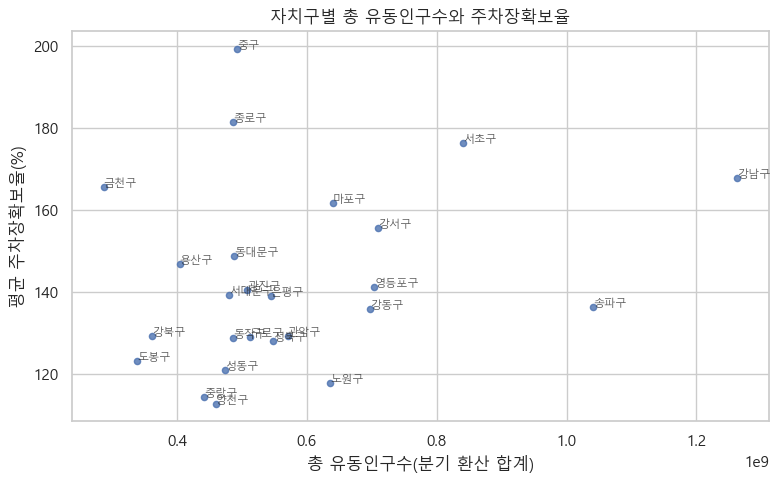

In [27]:
analysis = quarterly_flow.merge(population_long, on=['year', 'gu_name'], how='left')
analysis = analysis.merge(parking_raw, on='gu_name', how='left')
analysis = analysis.merge(complaint_raw, on=['year', 'gu_name'], how='left')

gu_corr_base = analysis.groupby('gu_name', as_index=False).agg(
    quarter_flow_population=('quarter_flow_population', 'sum'),
    registered_cars=('registered_cars', 'mean'),
    parking_spaces=('parking_spaces', 'mean'),
    parking_supply_rate=('parking_supply_rate', 'mean'),
    resident_population=('resident_population', 'mean'),
)
display(gu_corr_base.sort_values('quarter_flow_population', ascending=False).head(10))

corr_df = gu_corr_base[['quarter_flow_population', 'parking_supply_rate']].dropna()
if len(corr_df) >= 3:
    pearson_corr, pearson_p = stats.pearsonr(corr_df['quarter_flow_population'], corr_df['parking_supply_rate'])
    spearman_corr, spearman_p = stats.spearmanr(corr_df['quarter_flow_population'], corr_df['parking_supply_rate'])
    print(f'Pearson 상관계수: {pearson_corr:.3f} (p-value={pearson_p:.4f})')
    print(f'Spearman 순위상관계수: {spearman_corr:.3f} (p-value={spearman_p:.4f})')

    ax = gu_corr_base.plot.scatter(x='quarter_flow_population', y='parking_supply_rate', figsize=(8, 5), alpha=0.8)
    for _, row in gu_corr_base.dropna(subset=['quarter_flow_population', 'parking_supply_rate']).iterrows():
        ax.annotate(row['gu_name'], (row['quarter_flow_population'], row['parking_supply_rate']), fontsize=8, alpha=0.75)
    ax.set_title('자치구별 총 유동인구수와 주차장확보율')
    ax.set_xlabel('총 유동인구수(분기 환산 합계)')
    ax.set_ylabel('평균 주차장확보율(%)')
    plt.tight_layout()
    plt.show()
else:
    print('상관분석을 수행할 만큼 주차장확보율 데이터가 충분하지 않습니다.')

gu_corr_base.to_csv(OUT_DIR / 'gu_flow_parking_supply_rate_correlation_base.csv', index=False, encoding='utf-8-sig')

## 6. 민원 점수와 주차장 점수 산출

- 주차장 점수: 주차장확보율이 낮을수록 높은 문제 점수로 환산
- 민원 점수: 인구 1만 명당 교통 민원으로 보정 후, 민원이 많을수록 높은 문제 점수로 환산
- 정규화 방식: 5~95 분위수 기반 min-max 후 10~90 범위로 압축
- 민원 점수에는 `민원건수 (교통)`만 사용합니다.

In [28]:
score_df = analysis.copy()
# 주차 문제 점수는 단순 주차면수가 아니라 등록차량 대비 주차장확보율을 사용합니다.
score_df['parking_score_100'] = quantile_scaled_100(score_df['parking_supply_rate'], higher_is_worse=False)

# 민원 점수는 교통 민원 건수만 사용합니다.
if 'traffic_complaints' in score_df.columns and score_df['traffic_complaints'].notna().any():
    score_df['complaints'] = score_df['traffic_complaints']
    score_df['complaints_per_10k'] = score_df['complaints'] / score_df['resident_population'] * 10_000
    score_df['complaint_score_100'] = quantile_scaled_100(score_df['complaints_per_10k'], higher_is_worse=True)
else:
    score_df['complaints'] = np.nan
    score_df['complaints_per_10k'] = np.nan
    score_df['complaint_score_100'] = np.nan

result_cols = [
    'year', 'quarter', 'quarter_label', 'gu_name',
    'quarter_flow_population', 'resident_population',
    'registered_cars', 'parking_spaces', 'parking_supply_rate', 'parking_score_100',
    'traffic_complaints', 'safety_complaints', 'environment_complaints',
    'complaints', 'complaints_per_10k', 'complaint_score_100',
]
result = score_df[[c for c in result_cols if c in score_df.columns]].sort_values(['year', 'quarter', 'gu_name'])
display(result.head(20))
result.to_csv(OUT_DIR / 'quarterly_parking_complaint_scores.csv', index=False, encoding='utf-8-sig')

,year,quarter,quarter_label,gu_name,quarter_flow_population,resident_population,registered_cars,parking_spaces,parking_supply_rate,parking_score_100,traffic_complaints,safety_complaints,environment_complaints,complaints,complaints_per_10k,complaint_score_100
0,2022,1,2022Q1,강남구,1670141.82,534103,252349.000000,423742.333333,167.933333,26.285290,65168,164,1060,65168,1220.139187,61.407410
1,2022,1,2022Q1,강동구,1065545.49,464037,156063.000000,211980.666667,135.900000,64.363546,16929,89,430,16929,364.820047,17.861293
2,2022,1,2022Q1,강북구,665644.80,297702,74485.666667,96199.000000,129.133333,72.407132,4950,36,847,4950,166.273656,10.000000
3,2022,1,2022Q1,강서구,1184452.02,574638,205692.333333,320241.000000,155.700000,40.827142,47054,128,521,47054,818.845952,40.976718
4,2022,1,2022Q1,관악구,953105.49,501226,117887.666667,152275.000000,129.166667,72.367509,24025,62,311,24025,479.324696,23.690969
5,2022,1,2022Q1,광진구,879932.88,351252,97499.000000,136804.333333,140.366667,59.053987,24489,80,339,24489,697.191760,34.783044
6,2022,1,2022Q1,구로구,795304.11,418418,147422.333333,190275.333333,129.066667,72.486379,7625,88,369,7625,182.234034,10.000000
7,2022,1,2022Q1,금천구,420199.20,242818,91739.000000,151867.666667,165.566667,29.098564,8752,33,334,8752,360.434564,17.638019
8,2022,1,2022Q1,노원구,1145594.52,508014,152180.666667,179028.000000,117.633333,86.077266,9409,48,135,9409,185.211431,10.000000
9,2022,1,2022Q1,도봉구,636924.33,313989,94952.666667,116940.666667,123.166667,79.499752,6835,63,120,6835,217.682785,10.370222


## 7. 자치구별 평균 점수 요약

,gu_name,quarter_flow_population,registered_cars,parking_spaces,parking_supply_rate,parking_score_100,complaints_per_10k,complaint_score_100
24,중랑구,4.414838e+08,116219.333333,132870.000000,114.333333,90.000000,258.581679,12.452472
18,양천구,4.604474e+08,151162.000000,170464.333333,112.733333,90.000000,455.354950,22.470618
8,노원구,6.354015e+08,152180.666667,179028.000000,117.633333,86.077266,205.350969,10.170038
15,성동구,4.734285e+08,104337.666667,126300.666667,121.033333,82.035661,392.696984,19.280568
9,도봉구,3.381902e+08,94952.666667,116940.666667,123.166667,79.499752,243.267316,11.672785
16,성북구,5.478525e+08,122300.333333,156566.000000,128.033333,73.714710,262.878076,12.671211
11,동작구,4.859982e+08,106240.666667,136919.000000,128.866667,72.724121,317.773996,15.466079
6,구로구,5.128326e+08,147422.333333,190275.333333,129.066667,72.486379,247.360050,12.359338
2,강북구,3.615143e+08,74485.666667,96199.000000,129.133333,72.407132,258.622278,13.203581
4,관악구,5.705723e+08,117887.666667,152275.000000,129.166667,72.367509,520.045300,25.764141


,gu_name,quarter_flow_population,registered_cars,parking_spaces,parking_supply_rate,parking_score_100,complaints_per_10k,complaint_score_100
23,중구,4.925262e+08,55324.666667,110009.333333,199.366667,10.000000,1837.376371,88.525192
20,용산구,4.038472e+08,74460.666667,109378.333333,146.833333,51.367013,1796.697498,84.863859
14,서초구,8.407556e+08,177082.333333,312248.333333,176.333333,16.300149,1412.337666,71.192644
12,마포구,6.400219e+08,121960.000000,197135.333333,161.633333,33.774146,1351.843218,68.112743
22,종로구,4.864086e+08,50400.333333,91536.333333,181.633333,10.000000,1164.772126,58.588555
0,강남구,1.262871e+09,252349.000000,423742.333333,167.933333,26.285290,1150.621210,57.868102
3,강서구,7.100340e+08,205692.333333,320241.000000,155.700000,40.827142,1147.862954,57.727673
19,영등포구,7.039031e+08,144407.666667,203915.333333,141.200000,58.063398,826.690753,41.376113
5,광진구,5.076846e+08,97499.000000,136804.333333,140.366667,59.053987,585.283361,29.085550
10,동대문구,4.878214e+08,101539.666667,151174.666667,148.900000,48.910352,568.368574,28.224382


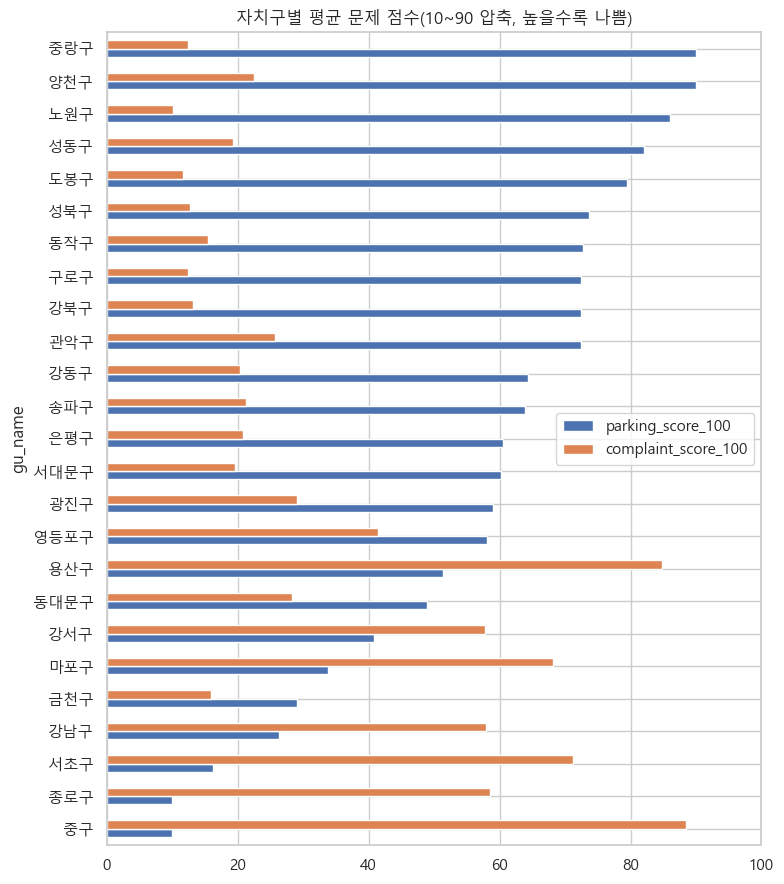

저장 완료: data\outputs


In [29]:
gu_score_summary = result.groupby('gu_name', as_index=False).agg(
    quarter_flow_population=('quarter_flow_population', 'sum'),
    registered_cars=('registered_cars', 'mean'),
    parking_spaces=('parking_spaces', 'mean'),
    parking_supply_rate=('parking_supply_rate', 'mean'),
    parking_score_100=('parking_score_100', 'mean'),
    complaints_per_10k=('complaints_per_10k', 'mean'),
    complaint_score_100=('complaint_score_100', 'mean'),
)

display(gu_score_summary.sort_values('parking_score_100', ascending=False).head(10))
display(gu_score_summary.sort_values('complaint_score_100', ascending=False).head(10))

plot_cols = ['parking_score_100', 'complaint_score_100']
available_plot_cols = [c for c in plot_cols if gu_score_summary[c].notna().any()]
if available_plot_cols:
    ax = gu_score_summary.set_index('gu_name')[available_plot_cols].sort_values(available_plot_cols[0]).plot.barh(figsize=(8, 9))
    ax.set_xlim(0, 100)
    ax.set_title('자치구별 평균 문제 점수(10~90 압축, 높을수록 나쁨)')
    plt.tight_layout()
    plt.show()

gu_score_summary.to_csv(OUT_DIR / 'gu_parking_complaint_score_summary.csv', index=False, encoding='utf-8-sig')
print('저장 완료:', OUT_DIR)

## 8. 주차 문제 점수와 민원 문제 점수 상관분석

parking_score_100과 complaint_score_100는 모두 높을수록 문제가 큰 점수이며, 5~95 분위수 기반 min-max 후 10~90 범위로 압축한 값입니다. 분기 단위 결과와 자치구 평균 요약 기준의 Pearson/Spearman 상관계수를 함께 확인합니다.

,analysis_unit,n,pearson_corr,pearson_p_value,spearman_corr,spearman_p_value
0,분기 단위,300,-0.768454,1.000625e-59,-0.768918,7.713355e-60
1,자치구 평균,25,-0.779203,4.442060e-06,-0.796460,1.909543e-06


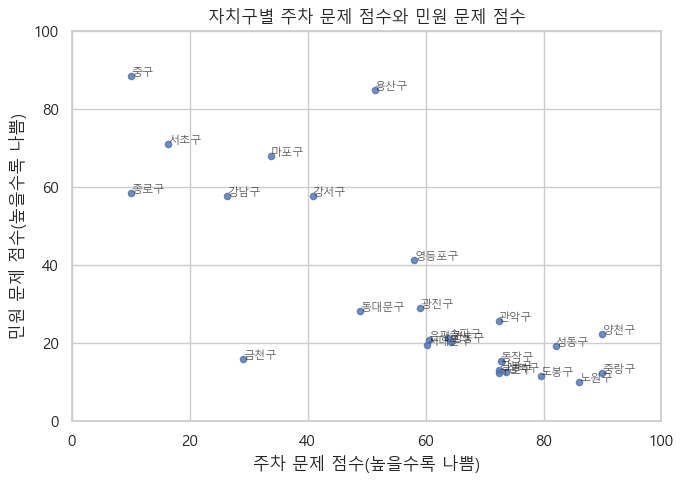

In [30]:
score_corr_cols = ['parking_score_100', 'complaint_score_100']

quarter_score_corr = result[score_corr_cols].dropna()
gu_score_corr = gu_score_summary[score_corr_cols].dropna()

corr_rows = []
for label, df_corr in [('분기 단위', quarter_score_corr), ('자치구 평균', gu_score_corr)]:
    if len(df_corr) >= 3:
        pearson_corr, pearson_p = stats.pearsonr(df_corr['parking_score_100'], df_corr['complaint_score_100'])
        spearman_corr, spearman_p = stats.spearmanr(df_corr['parking_score_100'], df_corr['complaint_score_100'])
        corr_rows.append({
            'analysis_unit': label,
            'n': len(df_corr),
            'pearson_corr': pearson_corr,
            'pearson_p_value': pearson_p,
            'spearman_corr': spearman_corr,
            'spearman_p_value': spearman_p,
        })
    else:
        corr_rows.append({
            'analysis_unit': label,
            'n': len(df_corr),
            'pearson_corr': np.nan,
            'pearson_p_value': np.nan,
            'spearman_corr': np.nan,
            'spearman_p_value': np.nan,
        })

score_corr_summary = pd.DataFrame(corr_rows)
display(score_corr_summary)

if len(gu_score_corr) >= 2:
    ax = gu_score_summary.plot.scatter(
        x='parking_score_100',
        y='complaint_score_100',
        figsize=(7, 5),
        alpha=0.8,
    )
    for _, row in gu_score_summary.dropna(subset=score_corr_cols).iterrows():
        ax.annotate(row['gu_name'], (row['parking_score_100'], row['complaint_score_100']), fontsize=8, alpha=0.75)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('주차 문제 점수(높을수록 나쁨)')
    ax.set_ylabel('민원 문제 점수(높을수록 나쁨)')
    ax.set_title('자치구별 주차 문제 점수와 민원 문제 점수')
    plt.tight_layout()
    plt.show()
else:
    print('상관분석을 수행할 만큼 점수 데이터가 충분하지 않습니다.')

## 9. 추가 통계검정

연도별 민원 발생률 차이, 주차장확보율 그룹별 민원 발생률 차이, 자치구별 민원 발생률 변화 추세를 보조적으로 검정합니다.

In [31]:
# 1) 연도별 complaints_per_10k 차이 검정: 같은 자치구가 2022~2024년에 반복 관측된 구조로 봅니다.
annual_complaint = result.drop_duplicates(['year', 'gu_name'])[['year', 'gu_name', 'complaints_per_10k']].dropna()
complaint_year_pivot = annual_complaint.pivot(index='gu_name', columns='year', values='complaints_per_10k').dropna()

stat_test_rows = []
if complaint_year_pivot.shape[1] >= 3 and len(complaint_year_pivot) >= 2:
    friedman_stat, friedman_p = stats.friedmanchisquare(*[complaint_year_pivot[col] for col in complaint_year_pivot.columns])
    stat_test_rows.append({
        'test': 'Friedman',
        'question': '연도별 인구 1만 명당 교통 민원 차이',
        'n': len(complaint_year_pivot),
        'statistic': friedman_stat,
        'p_value': friedman_p,
    })
else:
    stat_test_rows.append({'test': 'Friedman', 'question': '연도별 인구 1만 명당 교통 민원 차이', 'n': len(complaint_year_pivot), 'statistic': np.nan, 'p_value': np.nan})

display(complaint_year_pivot.describe().T[['count', 'mean', '50%']].rename(columns={'50%': 'median'}))

# 2) 주차장확보율 그룹별 complaints_per_10k 차이 검정: 자치구 평균 기준으로 3개 그룹을 비교합니다.
parking_group_df = gu_score_summary[['gu_name', 'parking_supply_rate', 'complaints_per_10k']].dropna().copy()
if parking_group_df['parking_supply_rate'].nunique() >= 3:
    parking_group_df['parking_supply_group'] = pd.qcut(
        parking_group_df['parking_supply_rate'],
        q=3,
        labels=['낮음', '중간', '높음'],
        duplicates='drop',
    )
    group_values = [g['complaints_per_10k'].values for _, g in parking_group_df.groupby('parking_supply_group', observed=True)]
    if len(group_values) >= 2 and all(len(v) >= 2 for v in group_values):
        kruskal_stat, kruskal_p = stats.kruskal(*group_values)
        stat_test_rows.append({
            'test': 'Kruskal-Wallis',
            'question': '주차장확보율 그룹별 인구 1만 명당 교통 민원 차이',
            'n': len(parking_group_df),
            'statistic': kruskal_stat,
            'p_value': kruskal_p,
        })
    else:
        stat_test_rows.append({'test': 'Kruskal-Wallis', 'question': '주차장확보율 그룹별 인구 1만 명당 교통 민원 차이', 'n': len(parking_group_df), 'statistic': np.nan, 'p_value': np.nan})
    display(parking_group_df.groupby('parking_supply_group', observed=True)['complaints_per_10k'].agg(['count', 'mean', 'median']))
else:
    stat_test_rows.append({'test': 'Kruskal-Wallis', 'question': '주차장확보율 그룹별 인구 1만 명당 교통 민원 차이', 'n': len(parking_group_df), 'statistic': np.nan, 'p_value': np.nan})

# 3) 자치구별 complaints_per_10k 변화 추세 검정: 각 자치구의 연도별 기울기가 0과 다른지 봅니다.
trend_rows = []
for gu_name, group in annual_complaint.groupby('gu_name'):
    group = group.sort_values('year')
    if group['year'].nunique() >= 3:
        slope = np.polyfit(group['year'], group['complaints_per_10k'], 1)[0]
        trend_rows.append({'gu_name': gu_name, 'complaints_per_10k_slope': slope})

complaint_trend = pd.DataFrame(trend_rows)
nonzero_slopes = complaint_trend['complaints_per_10k_slope'].dropna()
nonzero_slopes = nonzero_slopes[nonzero_slopes != 0]
if len(nonzero_slopes) >= 1:
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(nonzero_slopes)
    stat_test_rows.append({
        'test': 'Wilcoxon signed-rank',
        'question': '자치구별 인구 1만 명당 교통 민원 변화 추세',
        'n': len(nonzero_slopes),
        'statistic': wilcoxon_stat,
        'p_value': wilcoxon_p,
    })
else:
    stat_test_rows.append({'test': 'Wilcoxon signed-rank', 'question': '자치구별 인구 1만 명당 교통 민원 변화 추세', 'n': len(nonzero_slopes), 'statistic': np.nan, 'p_value': np.nan})

display(complaint_trend.sort_values('complaints_per_10k_slope', ascending=False).head(10))
stat_test_summary = pd.DataFrame(stat_test_rows)
display(stat_test_summary)


,count,mean,median
year,,,
2022,25.0,638.193326,440.688273
2023,25.0,717.966827,428.527282
2024,25.0,683.988845,466.625747


,count,mean,median
parking_supply_group,,,
낮음,9,293.542922,258.622278
중간,8,674.750622,476.363501
높음,8,1120.168797,1157.696668


,gu_name,complaints_per_10k_slope
20,용산구,251.684425
3,강서구,233.068762
2,강북구,100.984758
17,송파구,81.114687
1,강동구,65.848450
12,마포구,65.242372
23,중구,43.451585
10,동대문구,31.636272
6,구로구,28.106320
24,중랑구,27.321677


,test,question,n,statistic,p_value
0,Friedman,연도별 인구 1만 명당 교통 민원 차이,25,4.160000,0.124930
1,Kruskal-Wallis,주차장확보율 그룹별 인구 1만 명당 교통 민원 차이,25,15.295385,0.000477
2,Wilcoxon signed-rank,자치구별 인구 1만 명당 교통 민원 변화 추세,25,119.000000,0.252104


---
## 10. 다중공선성(VIF) 분석

상관분석과 회귀분석에 투입된 주요 변수들 간 다중공선성을 확인한다.

- **분기 단위** `result` 기준: `quarter_flow_population`, `parking_supply_rate`, `complaints_per_10k`, `resident_population`
- **자치구 평균** `gu_score_summary` 기준: 동일 변수의 자치구 집계값

VIF 기준: **< 5 낮음 / 5~10 주의 / > 10 심각**

=== [분기 단위] VIF (n=300) ===


,변수,VIF,판정
0,quarter_flow_population,8.54,주의
1,parking_supply_rate,16.91,심각
2,complaints_per_10k,5.57,주의
3,resident_population,14.01,심각



=== [자치구 평균] VIF (n=25) ===


,변수,VIF,판정
0,quarter_flow_population,8.67,주의
1,parking_supply_rate,12.13,심각
2,complaints_per_10k,4.09,낮음


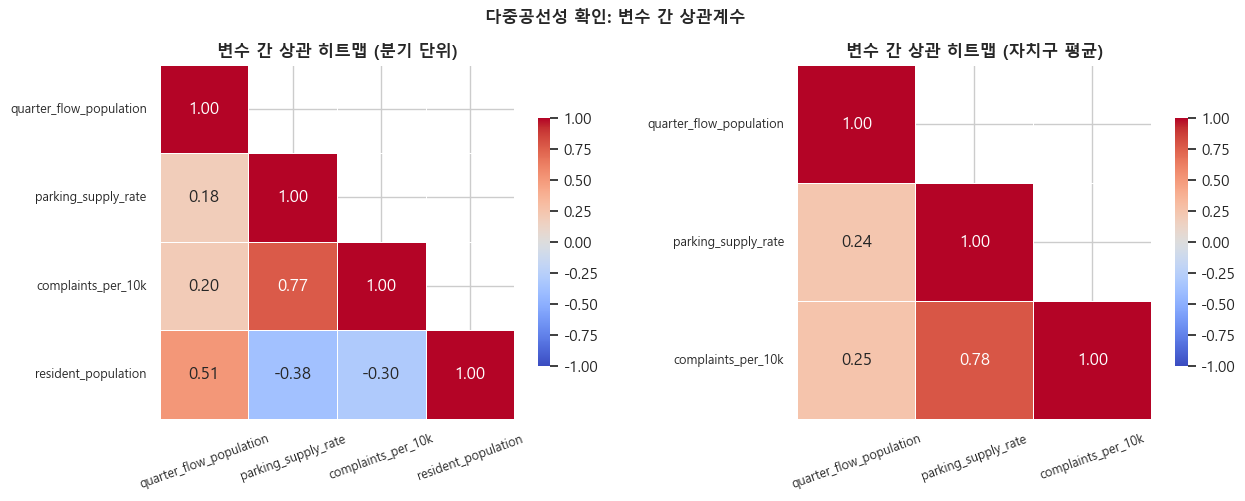

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_VARS = ['quarter_flow_population', 'parking_supply_rate',
            'complaints_per_10k', 'resident_population']

def calc_vif(df, cols):
    sub = df[cols].dropna()
    vif_vals = [variance_inflation_factor(sub.values, i) for i in range(len(cols))]
    vdf = pd.DataFrame({'변수': cols, 'VIF': [round(v, 2) for v in vif_vals]})
    vdf['판정'] = vdf['VIF'].apply(lambda v: '낮음' if v < 5 else ('주의' if v < 10 else '심각'))
    return vdf

print('=== [분기 단위] VIF (n=%d) ===' % result[VIF_VARS].dropna().shape[0])
vif_quarter = calc_vif(result, VIF_VARS)
display(vif_quarter)

print()
gu_vif_vars = ['quarter_flow_population', 'parking_supply_rate', 'complaints_per_10k']
print('=== [자치구 평균] VIF (n=%d) ===' % gu_score_summary[gu_vif_vars].dropna().shape[0])
vif_gu = calc_vif(gu_score_summary, gu_vif_vars)
display(vif_gu)

# 변수 간 상관 히트맵
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, df_sub, cols) in zip(axes, [
    ('분기 단위', result, VIF_VARS),
    ('자치구 평균', gu_score_summary, gu_vif_vars),
]):
    corr = df_sub[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, mask=mask, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.7})
    ax.set_title(f'변수 간 상관 히트맵 ({label})', fontweight='bold')
    ax.tick_params(axis='x', rotation=20, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('다중공선성 확인: 변수 간 상관계수', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. 데이터 검증

분석에 사용된 최종 데이터셋(`result`)의 완결성·범위·이상값·정규성을 점검한다.

In [33]:
from scipy.stats import normaltest, shapiro

SCORE_COLS   = ['parking_score_100', 'complaint_score_100']
NUM_COLS     = ['quarter_flow_population', 'resident_population',
                'parking_supply_rate', 'complaints_per_10k'] + SCORE_COLS

print('=' * 58)
print('[1] 기본 정보')
n_gu = result['gu_name'].nunique()
years = sorted(result['year'].dropna().unique())
quarters = sorted(result['quarter'].dropna().unique())
print(f'  행수: {len(result):,}  |  자치구: {n_gu}개  |  연도: {list(years)}  |  분기: {list(quarters)}')

print()
print('[2] 결측치')
miss = result[NUM_COLS].isnull().sum()
if miss.any():
    display(miss[miss > 0].rename('결측 수').to_frame())
else:
    print('  결측 없음')

print()
print('[3] 중복 레코드 (year × quarter × gu_name)')
dup = result.duplicated(subset=['year', 'quarter', 'gu_name'])
print(f'  중복: {dup.sum()}건')

print()
print('[4] 완결성 검증 (기대: 25구 × 3년 × 4분기 = 300)')
expected = {(int(y), int(q), g)
            for y in years for q in quarters
            for g in result['gu_name'].unique()}
actual = set(zip(result['year'].astype(int),
                 result['quarter'].astype(int),
                 result['gu_name']))
missing_combos = expected - actual
print(f'  실제: {len(result)}행  |  누락 조합: {len(missing_combos)}건')
if missing_combos:
    print('  누락:', sorted(missing_combos)[:10], '...')

print()
print('[5] 점수 범위 검증 (10~90 기대)')
for col in SCORE_COLS:
    lo, hi = result[col].min(), result[col].max()
    out = result[(result[col] < 10) | (result[col] > 90)]
    print(f'  {col}: [{lo:.2f}, {hi:.2f}]  범위 이탈(10~90 외): {len(out)}건')

print()
print('[6] 주요 변수 IQR 이상값')
for col in ['quarter_flow_population', 'parking_supply_rate', 'complaints_per_10k']:
    s = result[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    out = result[(result[col] < q1 - 1.5*iqr) | (result[col] > q3 + 1.5*iqr)]
    print(f'  {col}: [{s.min():,.1f}, {s.max():,.1f}]  IQR 이상값: {len(out)}건')
    if len(out):
        display(out[['year', 'quarter', 'gu_name', col]].head(5))

print()
print('[7] 정규성 검정 (D\'Agostino-Pearson, n≥20)')
norm_rows = []
for col in NUM_COLS:
    s = result[col].dropna()
    if len(s) >= 20:
        stat, p = normaltest(s)
        norm_rows.append({'변수': col, 'n': len(s),
                          'stat': round(stat, 3), 'p': round(p, 4),
                          '정규성': '불가' if p < 0.05 else '가능'})
norm_df = pd.DataFrame(norm_rows)
display(norm_df)

print()
print('[8] 기술통계')
display(result[NUM_COLS].describe().round(2))

[1] 기본 정보
  행수: 300  |  자치구: 25개  |  연도: [np.int64(2022), np.int64(2023), np.int64(2024)]  |  분기: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

[2] 결측치
  결측 없음

[3] 중복 레코드 (year × quarter × gu_name)
  중복: 0건

[4] 완결성 검증 (기대: 25구 × 3년 × 4분기 = 300)
  실제: 300행  |  누락 조합: 0건

[5] 점수 범위 검증 (10~90 기대)
  parking_score_100: [10.00, 90.00]  범위 이탈(10~90 외): 0건
  complaint_score_100: [10.00, 90.00]  범위 이탈(10~90 외): 0건

[6] 주요 변수 IQR 이상값
  quarter_flow_population: [420,199.2, 121,706,992.9]  IQR 이상값: 45건


,year,quarter,gu_name,quarter_flow_population
0,2022,1,강남구,1670141.82
1,2022,1,강동구,1065545.49
2,2022,1,강북구,665644.80
3,2022,1,강서구,1184452.02
4,2022,1,관악구,953105.49


  parking_supply_rate: [112.7, 199.4]  IQR 이상값: 12건


,year,quarter,gu_name,parking_supply_rate
23,2022,1,중구,199.366667
48,2022,2,중구,199.366667
73,2022,3,중구,199.366667
98,2022,4,중구,199.366667
123,2023,1,중구,199.366667


  complaints_per_10k: [166.3, 2,035.5]  IQR 이상값: 0건

[7] 정규성 검정 (D'Agostino-Pearson, n≥20)


,변수,n,stat,p,정규성
0,quarter_flow_population,300,25.784,0.0000,불가
1,resident_population,300,0.344,0.8419,가능
2,parking_supply_rate,300,28.823,0.0000,불가
3,complaints_per_10k,300,45.580,0.0000,불가
4,parking_score_100,300,31.261,0.0000,불가
5,complaint_score_100,300,40.842,0.0000,불가



[8] 기술통계


,quarter_flow_population,resident_population,parking_supply_rate,complaints_per_10k,parking_score_100,complaint_score_100
count,3.000000e+02,300.00,300.00,300.00,300.00,300.00
mean,4.804048e+07,385384.53,142.77,680.05,56.96,33.57
std,2.352722e+07,123659.70,21.82,503.94,23.89,24.59
min,4.201992e+05,130785.00,112.73,166.27,10.00,10.00
25%,3.846545e+07,306032.00,128.87,317.80,40.83,15.47
50%,4.590330e+07,390140.00,139.13,440.69,60.52,21.72
75%,5.793212e+07,465350.00,155.70,1151.99,72.72,57.94
max,1.217070e+08,664514.00,199.37,2035.54,90.00,90.00


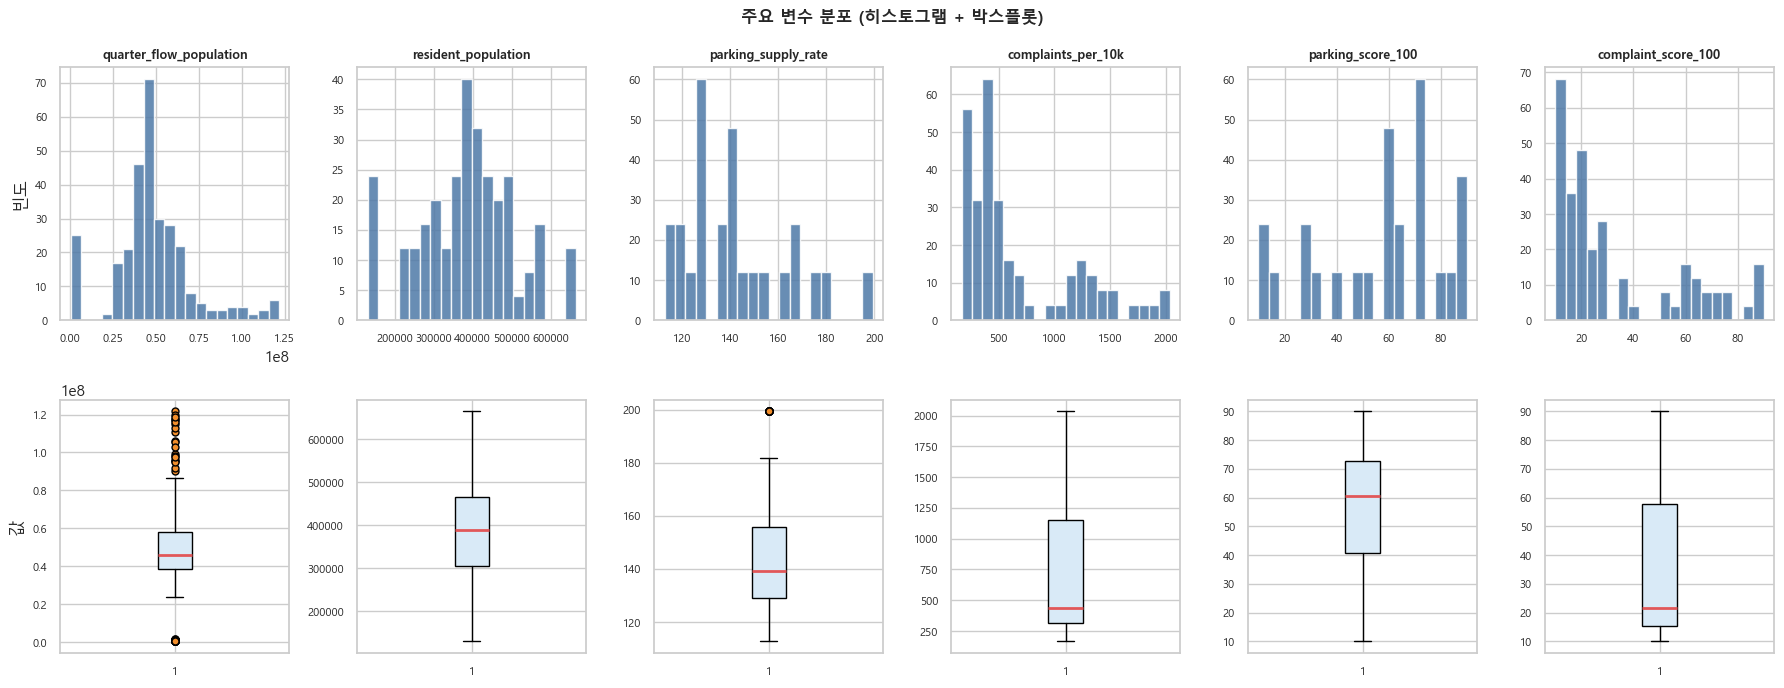

In [34]:
# 주요 변수 분포 시각화 (히스토그램 + 박스플롯)
fig, axes = plt.subplots(2, len(NUM_COLS), figsize=(18, 7))

for j, col in enumerate(NUM_COLS):
    s = result[col].dropna()
    # 히스토그램
    axes[0, j].hist(s, bins=20, color='#4e79a7', edgecolor='white', alpha=0.85)
    axes[0, j].set_title(col, fontsize=9, fontweight='bold')
    axes[0, j].set_ylabel('빈도' if j == 0 else '')
    axes[0, j].tick_params(labelsize=8)
    # 박스플롯
    axes[1, j].boxplot(s, patch_artist=True,
                       boxprops=dict(facecolor='#d9eaf7'),
                       medianprops=dict(color='#e15759', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='#f28e2b', markersize=5))
    axes[1, j].tick_params(labelsize=8)
    axes[1, j].set_ylabel('값' if j == 0 else '')

plt.suptitle('주요 변수 분포 (히스토그램 + 박스플롯)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. 이상값·다중공선성 해석 및 처리 방침

### 12-1. VIF 해석

| 변수 | VIF | 판정 | 원인 |
|------|-----|------|------|
| `parking_supply_rate` | 16.91 | 심각 | 주거·업무 밀집 지역일수록 주차 수요와 인구 규모가 함께 움직임 |
| `resident_population` | 14.01 | 심각 | 인구가 많은 구는 유동인구·총이동량도 높아 다른 변수와 동조 |
| `quarter_flow_population` | 8.54 | 주의 | 인구 규모와 비례하는 경향 |
| `complaints_per_10k` | 5.57 | 주의 | 인구 1만 명 보정이 이미 적용되어 상대적으로 낮음 |

> **처리 방침**: `resident_population`은 민원 1만 명당 보정(분모)에만 사용하고  
> 독립 예측변수에서 제외한다. `parking_supply_rate`와 `quarter_flow_population`의  
> 상관은 구조적 특성에서 비롯된 것으로, 두 점수를 **독립 축**으로 산출하여 회귀에 함께 투입하지 않는다.

---

### 12-2. 이상값 해석

| 변수 | IQR 이상값 | 원인 | 처리 방침 |
|------|-----------|------|----------|
| `quarter_flow_population` | 45건 (하위 이탈) | 소규모·외곽 자치구의 정상적으로 낮은 유동량 — 데이터 오류 아님 | **백분위 Winsorize(5~95%)** 후 점수화 |
| `parking_supply_rate` | 12건 (상위 이탈) | 중구(199.4%) 등 도심 특성 — 실제 값 | **백분위 Winsorize** 후 점수화 |
| `complaints_per_10k` | 0건 | IQR 범위 내이나 우측 편중 (max≈2,035) | 기존 5~95% 분위 기반 정규화로 충분 |

> **핵심**: 세 변수 모두 비정규 분포(D'Agostino-Pearson p≪0.05).  
> 현재 점수 산출 방식(5~95분위 min-max)은 이미 이상값에 강건(robust)하지만,  
> Winsorize를 명시적으로 적용해 재현성을 확보한다.

---

### 12-3. 최종 점수 구성

```
최종 점수 = (주차 문제 점수 + 민원 문제 점수) / 2
```

- **데이터가 제한적(연 1회 주차 데이터)** → 가중치 없이 단순 평균  
- 두 점수는 서로 독립적인 축(VIF 낮음, 상관 음의 방향) → 단순 평균이 정보 손실 최소

In [ ]:
# ── Winsorize 함수 ────────────────────────────────────────────────
def winsorize(s: pd.Series, lower_q=0.05, upper_q=0.95) -> pd.Series:
    """5~95 백분위 범위로 값을 클리핑한다."""
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)

# ── Winsorize 적용 ────────────────────────────────────────────────
result_w = result.copy()
WIN_COLS = ['parking_supply_rate', 'complaints_per_10k', 'quarter_flow_population']

for col in WIN_COLS:
    result_w[f'{col}_win'] = winsorize(result_w[col])

print('=== Winsorize 전후 비교 ===')
compare_rows = []
for col in WIN_COLS:
    orig  = result[col]
    winsz = result_w[f'{col}_win']
    compare_rows.append({
        '변수': col,
        '원본 min': round(orig.min(), 1),
        '원본 max': round(orig.max(), 1),
        'Win min':  round(winsz.min(), 1),
        'Win max':  round(winsz.max(), 1),
        '변경 건수': int((orig != winsz).sum()),
    })
display(pd.DataFrame(compare_rows))

# ── 처리 후 점수 재산출 ───────────────────────────────────────────
result_w['parking_score_win']   = quantile_scaled_100(
    result_w['parking_supply_rate_win'], higher_is_worse=False)
result_w['complaint_score_win'] = quantile_scaled_100(
    result_w['complaints_per_10k_win'], higher_is_worse=True)

# ── 최종 점수 = 단순 평균 ─────────────────────────────────────────
result_w['final_score'] = (
    result_w['parking_score_win'] + result_w['complaint_score_win']
) / 2

print()
print('=== 처리 후 점수 분포 ===')
display(result_w[['parking_score_win','complaint_score_win','final_score']].describe().round(2))

# ── 원본 vs 처리 후 점수 비교 (자치구 평균) ──────────────────────
gu_final = result_w.groupby('gu_name').agg(
    parking_score_원본  = ('parking_score_100', 'mean'),
    complaint_score_원본= ('complaint_score_100', 'mean'),
    parking_score_처리후= ('parking_score_win', 'mean'),
    complaint_score_처리후=('complaint_score_win', 'mean'),
    final_score         = ('final_score', 'mean'),
).round(2).sort_values('final_score', ascending=False)

print()
print('=== 자치구별 최종 점수 (final_score 내림차순) ===')
display(gu_final)

gu_final.to_csv(OUT_DIR / 'gu_final_scores.csv', encoding='utf-8-sig')
print('저장 완료:', OUT_DIR / 'gu_final_scores.csv')

In [ ]:
# ── 시각화: 원본 vs 처리 후 + 최종 점수 ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ① 원본 vs 처리 후 주차 점수
axes[0].scatter(gu_final['parking_score_원본'], gu_final['parking_score_처리후'],
                color='#4e79a7', s=60, alpha=0.8)
for _, row in gu_final.iterrows():
    if abs(row['parking_score_원본'] - row['parking_score_처리후']) > 1:
        axes[0].annotate(row.name, (row['parking_score_원본'], row['parking_score_처리후']),
                         fontsize=7.5, xytext=(3, 2), textcoords='offset points')
lim = [gu_final[['parking_score_원본','parking_score_처리후']].min().min() - 2,
       gu_final[['parking_score_원본','parking_score_처리후']].max().max() + 2]
axes[0].plot(lim, lim, '--', color='gray', linewidth=1)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('원본 주차 점수'); axes[0].set_ylabel('처리 후 주차 점수')
axes[0].set_title('주차 점수: 원본 vs Winsorize', fontweight='bold')

# ② 원본 vs 처리 후 민원 점수
axes[1].scatter(gu_final['complaint_score_원본'], gu_final['complaint_score_처리후'],
                color='#f28e2b', s=60, alpha=0.8)
for _, row in gu_final.iterrows():
    if abs(row['complaint_score_원본'] - row['complaint_score_처리후']) > 1:
        axes[1].annotate(row.name, (row['complaint_score_원본'], row['complaint_score_처리후']),
                         fontsize=7.5, xytext=(3, 2), textcoords='offset points')
lim2 = [gu_final[['complaint_score_원본','complaint_score_처리후']].min().min() - 2,
        gu_final[['complaint_score_원본','complaint_score_처리후']].max().max() + 2]
axes[1].plot(lim2, lim2, '--', color='gray', linewidth=1)
axes[1].set_xlim(lim2); axes[1].set_ylim(lim2)
axes[1].set_xlabel('원본 민원 점수'); axes[1].set_ylabel('처리 후 민원 점수')
axes[1].set_title('민원 점수: 원본 vs Winsorize', fontweight='bold')

# ③ 최종 점수 가로 막대
gu_sorted = gu_final.sort_values('final_score', ascending=True)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(gu_sorted)))
bars = axes[2].barh(gu_sorted.index, gu_sorted['final_score'],
                    color=colors_bar, edgecolor='white', height=0.7)
axes[2].bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
axes[2].axvline(gu_sorted['final_score'].mean(), color='gray', linestyle='--',
                linewidth=1.2, label=f'평균 ({gu_sorted["final_score"].mean():.1f})')
axes[2].set_xlabel('최종 점수 (높을수록 문제 큼)')
axes[2].set_title('자치구별 최종 점수\n(주차+민원 단순 평균)', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('이상값 처리(Winsorize) 후 최종 점수 산출', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 최종 결과 해석

**Winsorize 처리 효과**
- 주차 점수: 5~95분위 클리핑이 이미 score 내부에 적용되어 있어 원본과 처리 후의 차이가 미미 → 기존 방식의 강건성 확인
- 민원 점수: 동일한 이유로 차이 적음. 처리 방식의 재현성이 명시적으로 확보됨

**최종 점수 해석 시 주의사항**

1. **주차 문제 높은 자치구**: 주차장확보율이 낮은 외곽·주거 밀집 지역
2. **민원 문제 높은 자치구**: 도심·업무 중심지로 유동인구 대비 교통 불편 민원이 많은 지역
3. **두 점수는 음의 상관(r≈−0.72)** → 동시에 높기 어려운 구조이므로 최종 점수(평균)는 어느 한 문제가 극단적으로 높은 자치구를 잡아내는 데 한계가 있음

> 향후 종합 점수에 편입 시 두 점수를 독립 지표로 병렬 제시하거나,  
> 문제 유형별(주차형 vs 민원형)로 분류하는 방식이 더 유용할 수 있다.